In [40]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
# generate a sequnce of date
date_rng = pd.date_range(
    start="2018-01-01",
    end="2023-12-31",
    freq="M"
)

In [42]:
# generate sales data with seasonality and noise
np.random.seed(42)
sales = 200 + \
    20 * np.sin(2 * np.pi * date_rng.month / 12) + \
        np.random.normal(0, 5, len(date_rng))

In [43]:
# creating a dataframe
df = pd.DataFrame(
    {
        "Date": date_rng,
        "Sales": sales
     }
)
df.set_index("Date", inplace=True)

### Line plot

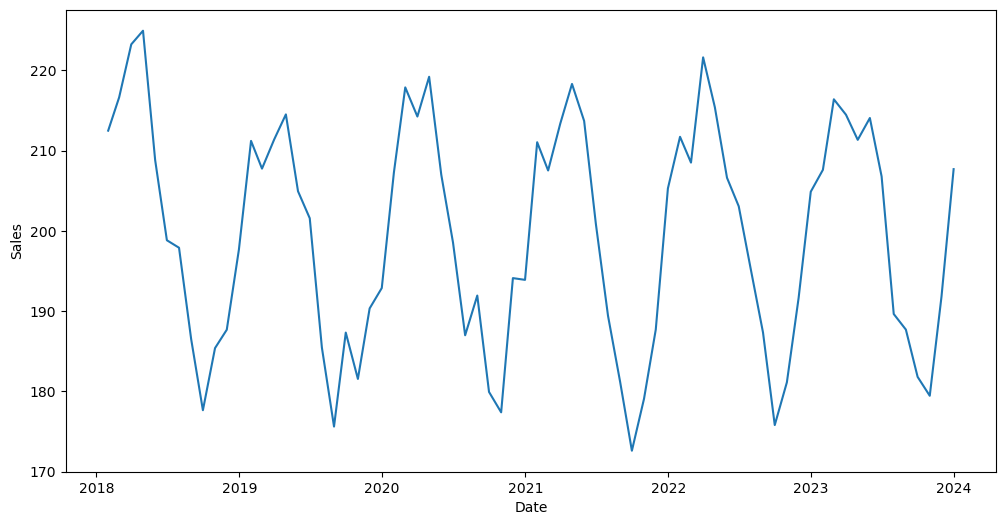

In [44]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=df.index, y=df["Sales"])
plt.show()

### Boxplot

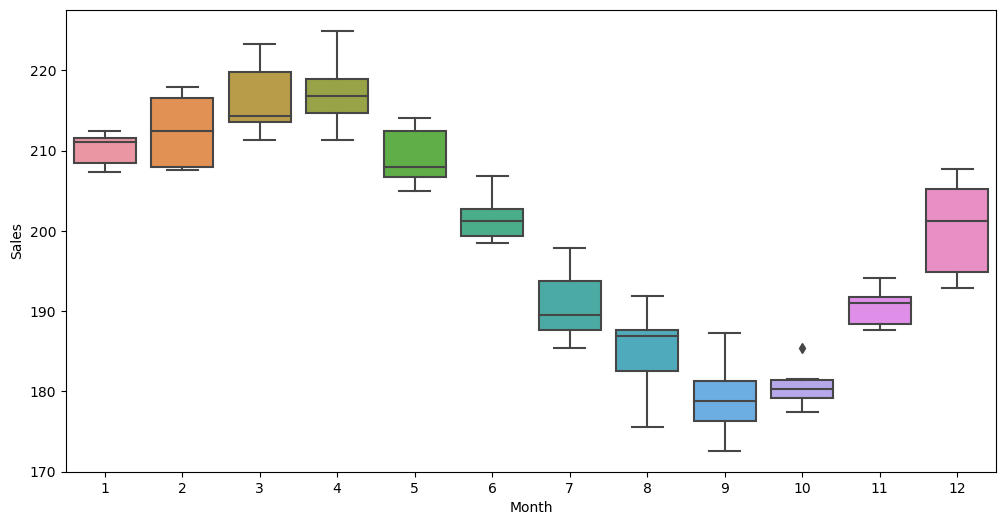

In [45]:
# Box Plot by Month
df["Month"] = df.index.month
plt.figure(figsize=(12, 6))
sns.boxplot(x=df["Month"], y=df["Sales"], data=df)
plt.show()

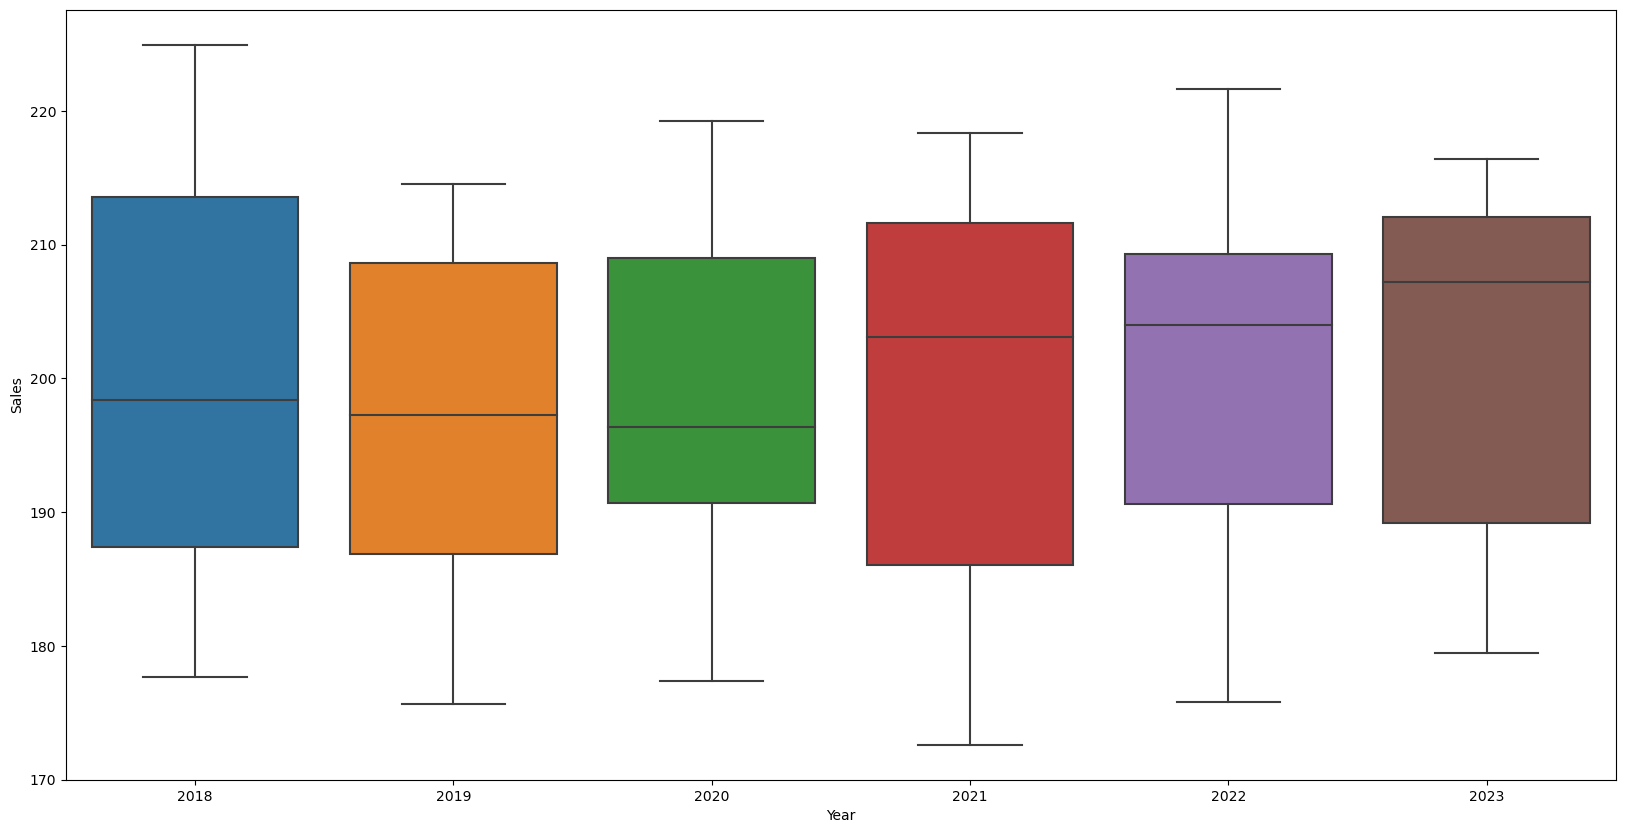

In [46]:
# Box plot by Year
df["Year"] = df.index.year
plt.figure(figsize=(20, 10))
sns.boxplot(x='Year', y='Sales', data=df)
plt.show()

In [47]:
df.head()

,Sales,Month,Year
Date,,,
2018-01-31,212.483571,1,2018
2018-02-28,216.629187,2,2018
2018-03-31,223.238443,3,2018
2018-04-30,224.935657,4,2018
2018-05-31,208.829233,5,2018


In [48]:
# generating data for trend + seasonality + noise
np.random.seed(42)
trend = np.linspace(100, 300, len(date_rng))
seasonality = 30 * np.sin( 2 * np.pi * date_rng.month/ 12)
noise = np.random.normal(0, 8, len(date_rng))
sales = trend + seasonality + noise

In [49]:
df = pd.DataFrame(
    {
        "Date": date_rng,
        "Sales": sales
    }
)
df.set_index("Date", inplace=True)
df

,Sales
Date,
2018-01-31,118.973713
2018-02-28,127.691549
2018-03-31,140.815311
2018-04-30,146.615705
2018-05-31,124.394379
...,...
2023-08-31,270.779895
2023-09-30,264.442384
2023-10-31,263.224477


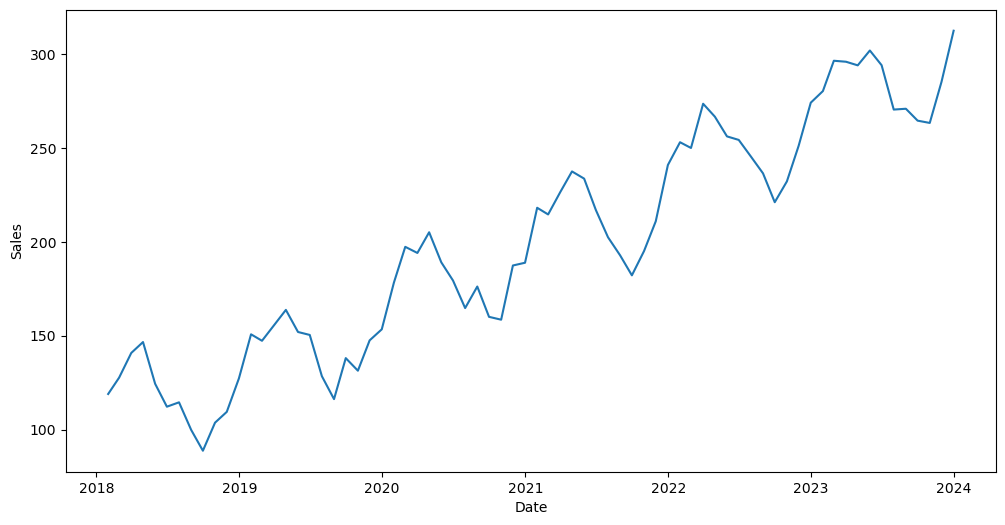

In [50]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=df.index, y='Sales', data=df)
plt.show()

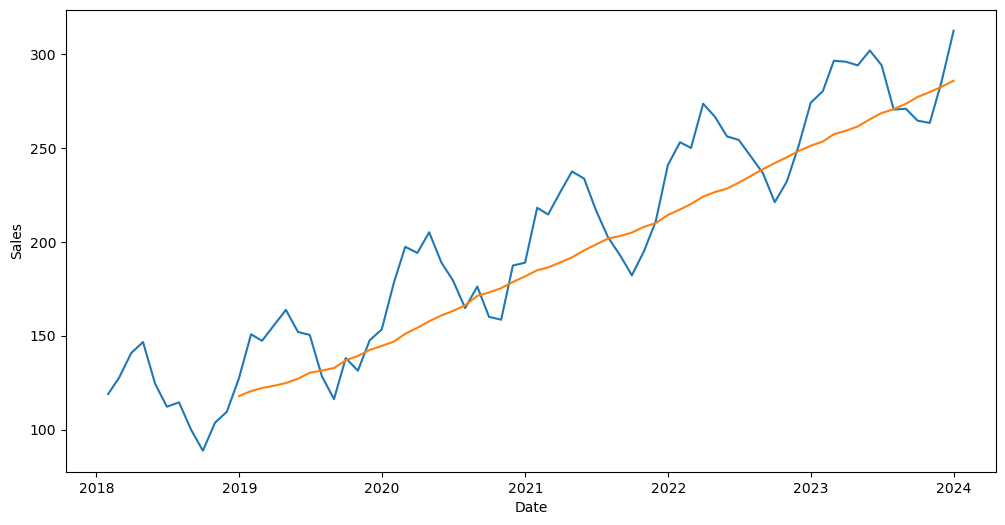

In [51]:
# highlight the trend by window size 12
df["RollingMean"] = df["Sales"].rolling(window=12).mean()
plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='Sales', data=df)
sns.lineplot(x='Date', y='RollingMean', data=df)
plt.show()

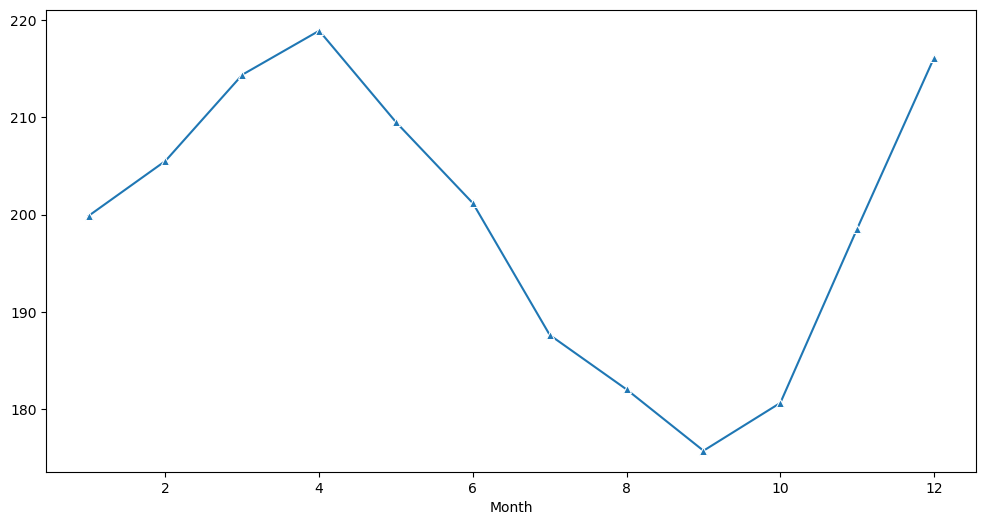

In [52]:
# identify the seasonality by month
df["Month"] = df.index.month
monthly_avg = df.groupby("Month")["Sales"].mean()
plt.figure(figsize=(12, 6))
sns.lineplot(x=monthly_avg.index, y=monthly_avg.values, marker='^')
plt.show()


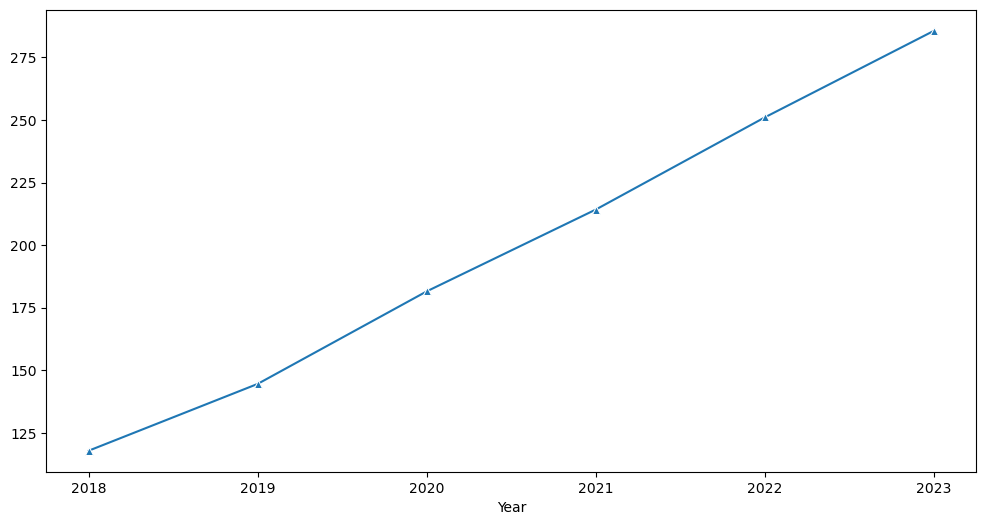

In [53]:
# cyclic behavior
df["Year"] = df.index.year
yearly_avg = df.groupby("Year")["Sales"].mean()
plt.figure(figsize=(12, 6))
sns.lineplot(x=yearly_avg.index, y=yearly_avg.values, marker='^')
plt.show()

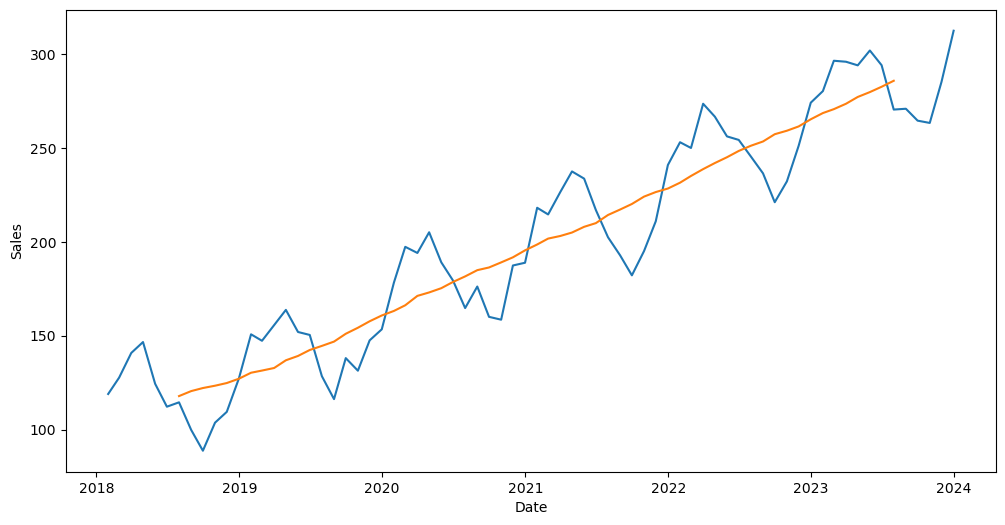

In [54]:
df["RollingMean"] = df["Sales"].rolling(window=12, center=True).mean()
plt.figure(figsize=(12, 6))
sns.lineplot(x=df.index, y='Sales', data=df)
sns.lineplot(x=df.index, y='RollingMean', data=df)
plt.show()

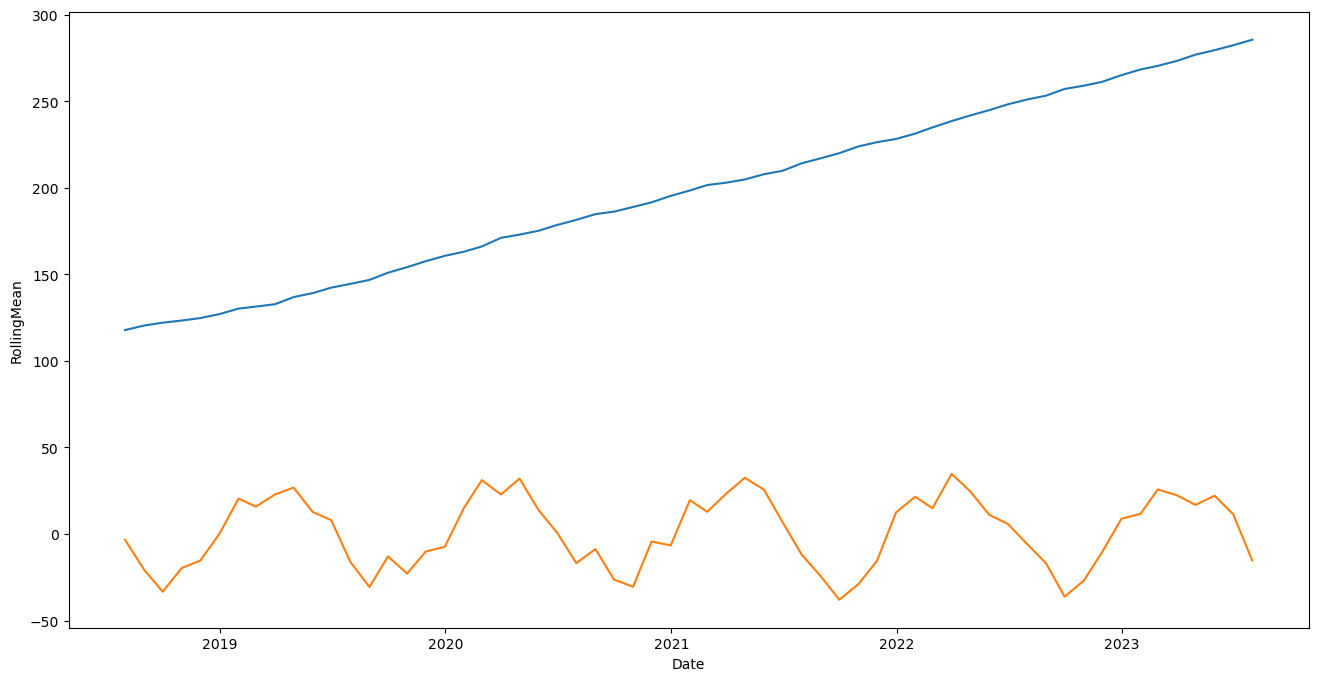

In [55]:
# random and irregular variations - detrending
df["Detrended"] = df["Sales"] - df["RollingMean"]
plt.figure(figsize=(16, 8))
sns.lineplot(x='Date', y='RollingMean', data=df) # trend
sns.lineplot(x='Date', y='Detrended', data=df) # random / irregular variations
plt.show()

In [56]:
!pip install statsmodels

### Time Series Analysis - Decomposition

In [57]:
from statsmodels.tsa.seasonal import seasonal_decompose

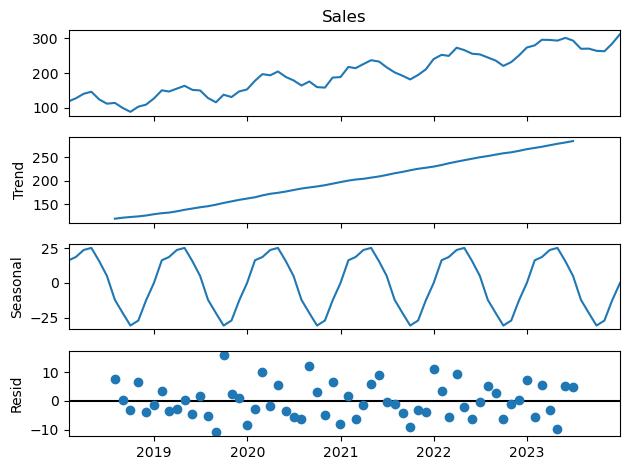

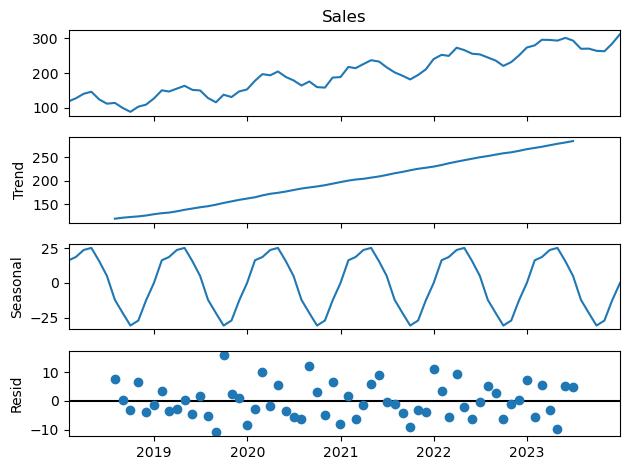

In [58]:
decompose_add = seasonal_decompose(df["Sales"], model="additive", period=12)
decompose_add.plot()

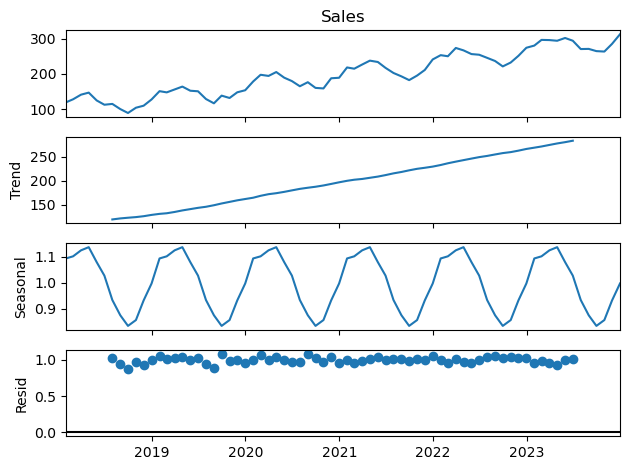

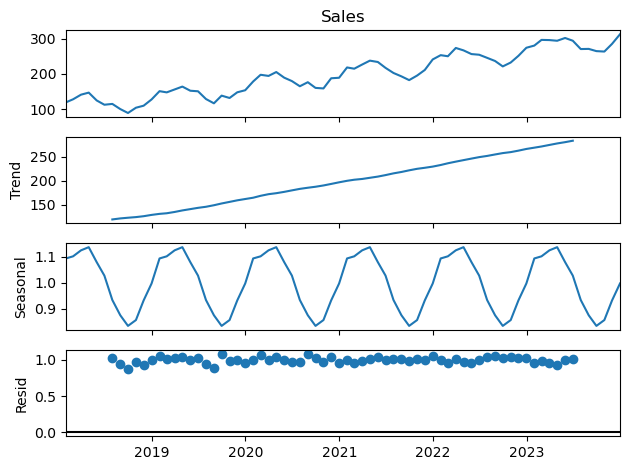

In [62]:
decompose_mul = seasonal_decompose(df["Sales"], model="multiplicative", period=12)
decompose_mul.plot()

In [63]:
df = df[["Sales"]]
df["Trend"] = decompose_add.trend
df["Seasonal"] = decompose_add.seasonal
df["Resid"] = decompose_add.resid
df

,Sales,Trend,Seasonal,Resid
Date,,,,
2018-01-31,118.973713,NaN,16.308268,NaN
2018-02-28,127.691549,NaN,18.612789,NaN
2018-03-31,140.815311,NaN,23.719885,NaN
2018-04-30,146.615705,NaN,25.188949,NaN
2018-05-31,124.394379,NaN,15.562966,NaN
...,...,...,...,...
2023-08-31,270.779895,NaN,-21.723845,NaN
2023-09-30,264.442384,NaN,-30.699225,NaN
2023-10-31,263.224477,NaN,-27.077644,NaN
